# CSSP Summer/Winter School - Example Notebook

This notebook investigates whether the anomalously hot austral summer of 2024 (December–February) in the state of **São Paulo, Brazil** was made more likely by human-caused climate change.

The climate variable of interest is the **Wet Bulb Globe Temperature (WBGT)**, a composite heat-stress index that integrates dry-bulb temperature, humidity, wind speed, and solar radiation. WBGT is widely used in occupational health and sports medicine to assess heat stress risk.

---

### What is Extreme Event Attribution?

Attribution science asks: **"Was this extreme event made more (or less) likely by human-caused climate change?"**

We compare two counterfactual worlds using large climate model ensembles:
- **ALL forcing** (factual world): includes all forcings — greenhouse gases, aerosols, natural variability
- **NAT forcing** (counterfactual world): includes only natural forcings — volcanic, solar

The key metrics we compute are:

**Probability Ratio (PR):**  
$$PR = \frac{P_{\text{ALL}}(X \geq x_0)}{P_{\text{NAT}}(X \geq x_0)}$$

A PR > 1 means the event became *more likely* in the world with human influence.

**Fraction of Attributable Risk (FAR):**  
$$FAR = 1 - \frac{1}{PR}$$

FAR represents the fraction of the event's probability that can be attributed to human influence.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# climattr — the attribution package we will use throughout
import climattr as eea

# scipy for distribution fitting
from scipy import stats

print("✅ All imports successful")

✅ All imports successful


In [ ]:
# ── File paths ─────────────────────────────────────────────────────────────
# Adjust these paths to point to your data files.

OBS_PATH  = '/gws/pw/j25/cssp_brazil/winter_school_2026/attribution/data/era5/wbgt/wbgt*'
ALL_PATH  = '/gws/pw/j25/cssp_brazil/winter_school_2026/attribution/data/HadGEM3-A-N216/historicalExt/wbgt/wbgt_*_HadGEM3-A-N216_historicalExt_*'
NAT_PATH  = '/gws/pw/j25/cssp_brazil/winter_school_2026/attribution/data/HadGEM3-A-N216/historicalNatExt/wbgt/wbgt_*_HadGEM3-A-N216_historicalNatExt_*'
HIST_PATH = '/gws/pw/j25/cssp_brazil/winter_school_2026/attribution/data/HadGEM3-A-N216/historical/wbgt/wbgt_*_HadGEM3-A-N216_historical_*_19600101-20131230.nc'

# ── Geographic bounds for the study region ─────────────────────────────────
# Update the coordinates below when switching to a different state or region.
# Tip: also update REGION_NAME in the User Options section below.
REGION_BOX = {
    'lon_min': -53.1, 'lon_max': -44.2,
    'lat_min': -25.3, 'lat_max': -19.8,
}

# ══════════════════════════════════════════════════════════════════════════════
# USER OPTIONS — change any of the settings below to adapt the notebook to a
# different variable, event year, season, or aggregation method.
# All downstream cells read from these variables automatically.
# ══════════════════════════════════════════════════════════════════════════════

# Region name — used in all plot titles.
# Update this whenever you change the REGION_BOX coordinates above.
# Examples: 'São Paulo State' | 'Minas Gerais' | 'Northeast Brazil'
REGION_NAME = 'São Paulo State'

# Variable to analyse — must match the variable name inside the NetCDF files.
# Options (depending on what is available in your data):
#   'wbgt'   — Wet Bulb Globe Temperature (heat stress)
#   'tasmax' — Daily maximum temperature
#   'tas'    — Daily mean temperature
#   'pr'     — Precipitation
#   'spei'   — Standardised Precipitation-Evapotranspiration Index
#   'fwi'    — Fire Weather Index
VARIABLE = 'wbgt'

# Reference period for the baseline climatology (start year, end year inclusive)
CLIM_PERIOD = [1980, 2010]

# Event year — the year whose seasonal anomaly is characterised and attributed
EVENT_YEAR = 2024

# Season — list of month numbers that define the season of interest.
#   DJF (austral summer) : [12, 1, 2]   ← current setting
#   MAM (austral autumn) : [3, 4, 5]
#   JJA (austral winter) : [6, 7, 8]
#   SON (austral spring)  : [9, 10, 11]
#   Custom example        : [1, 2]       (January–February only)
# Note: months spanning two calendar years (e.g. December + later months) are
# handled automatically — December is assigned to the following year.
SEASON_MONTHS = [12, 1, 2]

# Temporal aggregation — how daily values within each season are summarised.
#   'mean' — seasonal average (appropriate for temperature means, WBGT, SPEI)
#   'max'  — seasonal maximum (appropriate for extremes: hottest day, heaviest rain)
TEMPORAL_AGG = 'mean'

# Spatial aggregation — how grid points across the selected domain are summarised.
#   'mean' — area average (representative of typical conditions across the region)
#   'max'  — spatial maximum (worst-affected location within the domain)
SPATIAL_AGG = 'mean'

# Statistical distribution to fit to the seasonal data.
# Common choices (all available in scipy.stats):
#   'norm'        — Normal: appropriate for seasonal means (default)
#   'genextreme'  — GEV (Generalised Extreme Value): appropriate for annual maxima/minima
#   'gumbel_r'    — Gumbel: simpler alternative to GEV for block maxima
#   'gamma'       — Gamma: appropriate for precipitation and positive-only variables
#   'lognorm'     — Log-normal: appropriate for right-skewed data
DISTRIBUTION = 'norm'

# Bias correction method applied to the model ensembles before attribution.
# Set to None to skip bias correction entirely — appropriate when the variable
# is already normalised (e.g. SPEI, which is expressed in standard deviations
# relative to a reference climatology and has no physical unit bias).
#   None   — skip bias correction (recommended for SPEI and other indices)
#   'add'  — additive scaling: removes the mean offset between model and obs
#   'mult' — multiplicative scaling: corrects both mean and variance ratio
BIAS_CORRECTION_METHOD = 'add'

# Direction of the return period plot — controls which tail of the distribution
# is treated as extreme.
#   'descending' — high values are extreme (e.g. heat, heavy rainfall, high WBGT)
#                  Return period measures how often the event is exceeded upward.
#   'ascending'  — low values are extreme (e.g. drought / negative SPEI, cold events)
#                  Return period measures how often the event is exceeded downward.
DIRECTION = 'descending'

# ── Derived labels — computed from the options above, do not edit ───────────
_MONTH_ABBR  = {12:'D', 1:'J', 2:'F', 3:'M', 4:'A', 5:'M',
                6:'J', 7:'J', 8:'A', 9:'S', 10:'O', 11:'N'}
SEASON_LABEL = ''.join(_MONTH_ABBR.get(m, '?') for m in SEASON_MONTHS)
VAR_LABEL    = VARIABLE.upper()

print(f"Region   : {REGION_NAME}")
print(f"Variable : {VAR_LABEL}")
print(f"Season   : {SEASON_LABEL}  {SEASON_MONTHS}")
print(f"Event    : {EVENT_YEAR}")
print(f"Temporal : {TEMPORAL_AGG}  |  Spatial : {SPATIAL_AGG}")
print(f"Bias correction : {BIAS_CORRECTION_METHOD}")
print(f"Direction : {DIRECTION}")
print(f"Climatology : {CLIM_PERIOD[0]}–{CLIM_PERIOD[1]}")

Region   : São Paulo State
Variable : WBGT
Season   : DJF  [12, 1, 2]
Event    : 2024
Temporal : mean  |  Spatial : mean
Bias correction : None
Direction : descending
Climatology : 1980–2010


---
## Section 1 — Loading Pre-computed Data

We load the data directly and extract austral summer (DJF) annual mean for attribution analysis.

The `summer_annual_mean` helper below selects DJF months and returns the annual mean, labelling each season by its January year.

In [26]:
def summer_annual_mean(da, summer_months=None, temporal_agg='mean'):
    """
    Return the seasonal aggregate of a DataArray, labelled by year.

    Parameters
    ----------
    da : xr.DataArray
    summer_months : list of int, default [12, 1, 2]
        Months to include in the season.
    temporal_agg : {'mean', 'max'}, default 'mean'
        How to aggregate daily values within each season.
        Use 'mean' for seasonal averages and 'max' for seasonal extremes.

    Returns
    -------
    xr.DataArray
        Seasonally aggregated values indexed by year.

    Notes
    -----
    Seasons spanning two calendar years (e.g. DJF): December is assigned to
    the following year so each season is kept together
    (e.g. Dec 2023 + Jan 2024 + Feb 2024 → year label 2024).
    """
    if summer_months is None:
        summer_months = [12, 1, 2]

    da_summer = da.sel(time=da['time'].dt.month.isin(summer_months))
    year_label = da_summer['time'].dt.year.where(
        da_summer['time'].dt.month != 12,
        da_summer['time'].dt.year + 1
    )
    return getattr(da_summer.groupby(year_label), temporal_agg)(dim='time').rename({'year': 'time'})


print("✅ Helper functions defined")

✅ Helper functions defined


In [45]:
# ── Load pre-computed datasets ─────────────────────────────────────────────
print(f"Loading datasets (variable: {VARIABLE})...")
ds_obs  = xr.open_mfdataset(OBS_PATH)
ds_all  = xr.open_mfdataset(ALL_PATH,  concat_dim='ens', combine='nested')
ds_nat  = xr.open_mfdataset(NAT_PATH,  concat_dim='ens', combine='nested')
ds_hist = xr.open_mfdataset(HIST_PATH, concat_dim='ens', combine='nested')

# Rename coordinates if necessary
rename_map = {'valid_time': 'time', 'latitude': 'lat', 'longitude': 'lon'}
ds_obs = ds_obs.rename({k: v for k, v in rename_map.items() if k in ds_obs.coords})
ds_all = ds_all.rename({k: v for k, v in rename_map.items() if k in ds_all.coords})
ds_nat = ds_nat.rename({k: v for k, v in rename_map.items() if k in ds_nat.coords})
ds_hist = ds_hist.rename({k: v for k, v in rename_map.items() if k in ds_hist.coords})

da_obs  = ds_obs[VARIABLE]
da_hist = ds_hist[VARIABLE]
da_all  = ds_all[VARIABLE]
da_nat  = ds_nat[VARIABLE]

print("Observations shape          :", da_obs.shape)
print("Historical ALL forcing shape:", da_hist.shape)
print("ALL forcing shape           :", da_all.shape)
print("NAT forcing shape           :", da_nat.shape)

Loading datasets (variable: wbgt)...
Observations shape          : (16771, 157, 161)
Historical ALL forcing shape: (15, 19724, 70, 48)
ALL forcing shape           : (525, 1096, 70, 48)
NAT forcing shape           : (524, 1096, 70, 48)


---
## Section 2 — Spatial Masking

We isolate the **state of São Paulo** in two ways:

1. **Bounding box** — a rectangular selection covering the state's full extent (~44°W–53°W, ~20°S–25°S)
2. **Shapefile mask** *(recommended)* — the precise state boundary polygon from IBGE, which avoids including ocean and neighbouring states

`climattr`'s `filter.filter_area` function handles both approaches and returns a spatially averaged time series ready for attribution analysis.

> **📌 Geographic context:** The state of São Paulo spans roughly 248,000 km² across subtropical southeast Brazil. Shapefiles are freely available from IBGE (see Option B below).

Applying spatial mask...


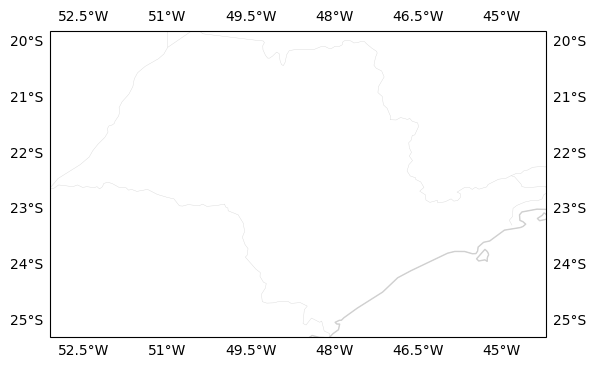

Spatial averaging complete
Obs   time range: ['1979-01-01T00:00:00.000000000' '2024-11-30T00:00:00.000000000']
HIST  time range: ['1960-01-01T12:00:00.000000000' '2013-12-31T12:00:00.000000000']
ALL   time range: ['2022-01-01T12:00:00.000000000' '2024-12-31T12:00:00.000000000']
NAT   time range: ['2022-01-01T12:00:00.000000000' '2024-12-31T12:00:00.000000000']


In [46]:
# ── Option A: Bounding box selection ───────────────────────────────────────
box = [
    REGION_BOX['lon_min'], REGION_BOX['lon_max'],
    REGION_BOX['lat_min'], REGION_BOX['lat_max'],
]

# climattr's filter_area returns a spatially averaged DataArray
# plot_area=True shows the selected region on a map
print("Applying spatial mask...")
obs_sp  = eea.filter.filter_area(da_obs.to_dataset(),  box=box, plot_area=True)
all_sp  = eea.filter.filter_area(da_all.to_dataset(),  box=box)
nat_sp  = eea.filter.filter_area(da_nat.to_dataset(),  box=box)
hist_sp = eea.filter.filter_area(da_hist.to_dataset(), box=box)

print("Spatial averaging complete")
print(f"Obs   time range: {str(obs_sp[VARIABLE]['time'].values[[0, -1]])}")
print(f"HIST  time range: {str(hist_sp[VARIABLE]['time'].values[[0, -1]])}")
print(f"ALL   time range: {str(all_sp[VARIABLE]['time'].values[[0, -1]])}")
print(f"NAT   time range: {str(nat_sp[VARIABLE]['time'].values[[0, -1]])}")

In [47]:
# ── Option B (optional): Shapefile mask ────────────────────────────────────
# If you have a shapefile for the state of São Paulo, use this instead:
#
# SHAPEFILE = 'data/sao_paulo_state.shp'
# obs_sp = eea.spatial.filter_area(wbgt_obs.to_dataset(), mask=SHAPEFILE, plot_area=True)
# all_sp = eea.spatial.filter_area(wbgt_all.to_dataset(), mask=SHAPEFILE)
# nat_sp = eea.spatial.filter_area(wbgt_nat.to_dataset(), mask=SHAPEFILE)
#
# Shapefiles for Brazilian states are freely available from IBGE:
# https://www.ibge.gov.br/geociencias/organizacao-do-territorio/malhas-territoriais
print("Shapefile masking commented out — remove comments above to use it")

Shapefile masking commented out — remove comments above to use it


In [48]:
# This cell takes a little while to run (~ 6 min) ...

# ── Compute seasonal aggregates and spatial summary ─────────────────────────
# summer_annual_mean groups by season using TEMPORAL_AGG (mean or max).
# getattr(..., SPATIAL_AGG) then collapses the spatial dims accordingly.
obs_djf  = summer_annual_mean(obs_sp[VARIABLE],  summer_months=SEASON_MONTHS, temporal_agg=TEMPORAL_AGG)
obs_djf  = getattr(obs_djf,  SPATIAL_AGG)(dim=['lat', 'lon']).load()

hist_djf = summer_annual_mean(hist_sp[VARIABLE], summer_months=SEASON_MONTHS, temporal_agg=TEMPORAL_AGG)
hist_djf = getattr(hist_djf, SPATIAL_AGG)(dim=['lat', 'lon']).load()

all_djf  = summer_annual_mean(all_sp[VARIABLE],  summer_months=SEASON_MONTHS, temporal_agg=TEMPORAL_AGG)
all_djf  = getattr(all_djf,  SPATIAL_AGG)(dim=['lat', 'lon']).load()

nat_djf  = summer_annual_mean(nat_sp[VARIABLE],  summer_months=SEASON_MONTHS, temporal_agg=TEMPORAL_AGG)
nat_djf  = getattr(nat_djf,  SPATIAL_AGG)(dim=['lat', 'lon']).load()

# Event: observed seasonal value for EVENT_YEAR
event_2024 = float(obs_djf.sel(time=EVENT_YEAR))

# Define threshold value
threshold = event_2024

# Select only the event year for attribution
all_djf = all_djf.sel(time=EVENT_YEAR)
nat_djf = nat_djf.sel(time=EVENT_YEAR)

print(f"Seasonal ({SEASON_LABEL}) {TEMPORAL_AGG}, spatial {SPATIAL_AGG} over domain:")
print(f"  Obs  — {len(obs_djf)} years,      mean = {float(obs_djf.mean()):.2f}")
print(f"  HIST — {len(hist_djf)} years,     mean = {float(hist_djf.mean()):.2f}")
print(f"  ALL  — {len(all_djf)} ensembles,  mean = {float(all_djf.mean()):.2f}")
print(f"  NAT  — {len(nat_djf)} ensembles,  mean = {float(nat_djf.mean()):.2f}")
print()
print(f"Event — {SEASON_LABEL} {EVENT_YEAR} {VAR_LABEL} (observed): {event_2024:.2f}")

Seasonal (DJF) mean, spatial mean over domain:
  Obs  — 46 years,      mean = 27.52
  HIST — 15 years,     mean = 26.42
  ALL  — 525 ensembles,  mean = 27.30
  NAT  — 524 ensembles,  mean = 25.95

Event — DJF 2024 WBGT (observed): 28.41


In [49]:
# ── Align obs and hist to the same year range ──────────────────────────────
common_years = np.intersect1d(obs_djf.time.values, hist_djf.time.values)
obs_djf_val  = obs_djf.sel(time=common_years)
hist_djf_val = hist_djf.sel(time=common_years)

print(f"Common     : {common_years[0]}–{common_years[-1]}  ({len(common_years)} years)")

Common     : 1979–2014  (36 years)


---
## Section 3 — Event Characterization

Before attributing the DJF 2024 event to climate change, we first characterise it in the context of the observed record: How unusual was it? What is its estimated return period?

Two plots from `climattr.exploratory` help answer this:

1. **Time series** — the full observational record
2. **Return period plot** — how often an event of this magnitude is expected to occur based on a fitted distribution

In [50]:
# ── Choose a distribution for fitting ──────────────────────────────────────────
# fit_function is derived from the DISTRIBUTION variable set in the config cell.
fit_function = getattr(stats, DISTRIBUTION)
print(f"Distribution selected: {fit_function.name}")

Distribution selected: norm


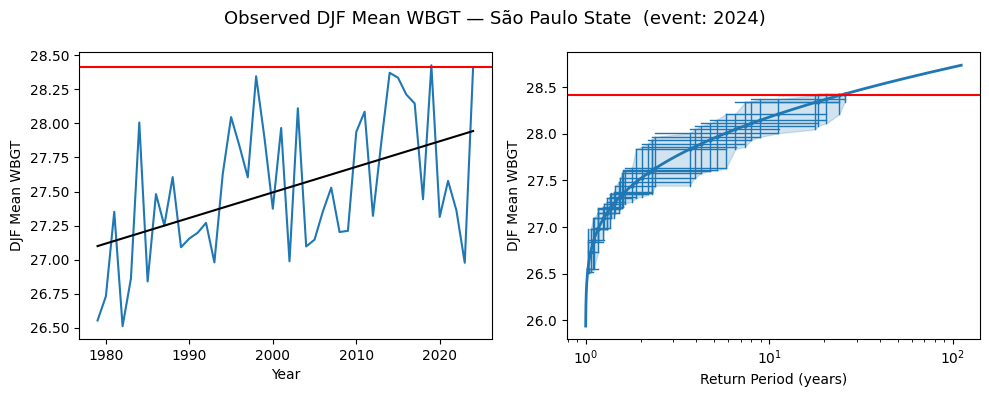

In [51]:
# ── Event characterisation — observations only ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

eea.exploratory.timeseries_plot(ax1, obs_djf, highlight_year=None, percentiles=None)
eea.exploratory.rp_plot(ax2, obs_djf, fit_function, highlight_year=None, direction=DIRECTION)

_ylabel = f'{SEASON_LABEL} {TEMPORAL_AGG.capitalize()} {VAR_LABEL}'
ax1.set_xlabel('Year')
ax1.set_ylabel(_ylabel)
ax2.set_xlabel('Return Period (years)')
ax2.set_ylabel(_ylabel)

ax1.axhline(event_2024, color='red')
ax2.axhline(event_2024, color='red')

fig.suptitle(
    f'Observed {SEASON_LABEL} {TEMPORAL_AGG.capitalize()} {VAR_LABEL} — {REGION_NAME}  (event: {EVENT_YEAR})',
    fontsize=13
)
plt.tight_layout()
plt.show()

### Spatial context: DJF 2024 WBGT anomaly

Before collapsing the data to a single area-average, it is useful to see **where** the anomalous warmth was concentrated. The map below shows the DJF 2024 WBGT departure from the 1980–2010 climatological mean at each ERA5 grid point. The black box marks the São Paulo bounding box used in the rest of the analysis.


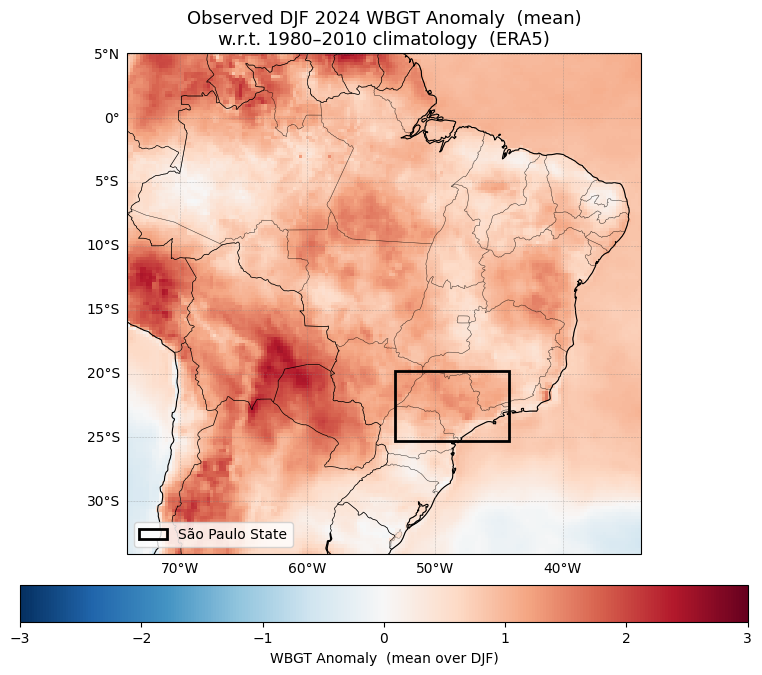

In [52]:
# ── Spatial map of seasonal anomaly ──────────────────────────────────────
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

# Compute seasonal aggregates preserving full spatial dimensions
obs_djf_spatial = summer_annual_mean(da_obs, summer_months=SEASON_MONTHS, temporal_agg=TEMPORAL_AGG)

# Reference-period climatology at each grid point (always mean across years)
clim_spatial = obs_djf_spatial.sel(
    time=slice(CLIM_PERIOD[0], CLIM_PERIOD[1])
).mean('time')

# Seasonal anomaly for EVENT_YEAR
anomaly_2024 = obs_djf_spatial.sel(time=EVENT_YEAR) - clim_spatial

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

vmax = np.ceil(float(np.abs(anomaly_2024).max()))
p = ax.pcolormesh(
    anomaly_2024['lon'], anomaly_2024['lat'], anomaly_2024,
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    transform=ccrs.PlateCarree()
)

ax.coastlines(resolution='50m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.3, alpha=0.5)

sp_rect = mpatches.Rectangle(
    (REGION_BOX['lon_min'], REGION_BOX['lat_min']),
    REGION_BOX['lon_max'] - REGION_BOX['lon_min'],
    REGION_BOX['lat_max'] - REGION_BOX['lat_min'],
    linewidth=2, edgecolor='black', facecolor='none',
    transform=ccrs.PlateCarree(), zorder=5, label=REGION_NAME
)
ax.add_patch(sp_rect)
ax.legend(handles=[sp_rect], loc='lower left', fontsize=10)

plt.colorbar(
    p, ax=ax,
    label=f'{VAR_LABEL} Anomaly  ({TEMPORAL_AGG} over {SEASON_LABEL})',
    orientation='horizontal', pad=0.05, shrink=0.75
)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                  alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title(
    f'Observed {SEASON_LABEL} {EVENT_YEAR} {VAR_LABEL} Anomaly  ({TEMPORAL_AGG})\n'
    f'w.r.t. {CLIM_PERIOD[0]}–{CLIM_PERIOD[1]} climatology  (ERA5)',
    fontsize=13
)
plt.tight_layout()
plt.show()

---
## Section 4 — Model Validation & Bias Correction

Before running attribution analysis, we check that the climate model reproduces observed statistics in the selected region. We use the **historical ALL-forcing simulation** (`hist`) for this comparison — it covers the period 1960–2014 and includes all historical forcings, so it should be comparable to the observations over the same years.

If a systematic bias is found, a **bias correction** can be applied to shift the ALL and NAT distributions before computing attribution metrics.

> **Do I need bias correction?**  
> Not always. For variables with physical units (temperature, precipitation, WBGT), models often have a mean offset or variance bias relative to observations, and correction is recommended. For **normalised indices such as SPEI**, bias correction is typically unnecessary — SPEI is already expressed as standard deviations relative to a reference climatology, so the units are already comparable between model and observations. In that case, set `BIAS_CORRECTION_METHOD = None` in the config cell to skip this step.

We use two diagnostic plots provided by `climattr`:

1. **Histogram + fitted distribution** — compares the shape of the observed and historical-model distributions
2. **Quantile-Quantile (QQ) plot** — shows whether model quantiles match observations across the full distribution

> **What to look for:**
> - Histogram: Do the distribution peaks and spreads align?
> - QQ plot: Do points fall close to the 1:1 diagonal? A systematic offset suggests an additive bias; a slope deviation suggests a scaling bias.
> - Pay particular attention to the tail on the extreme side — this is where attribution is most sensitive.

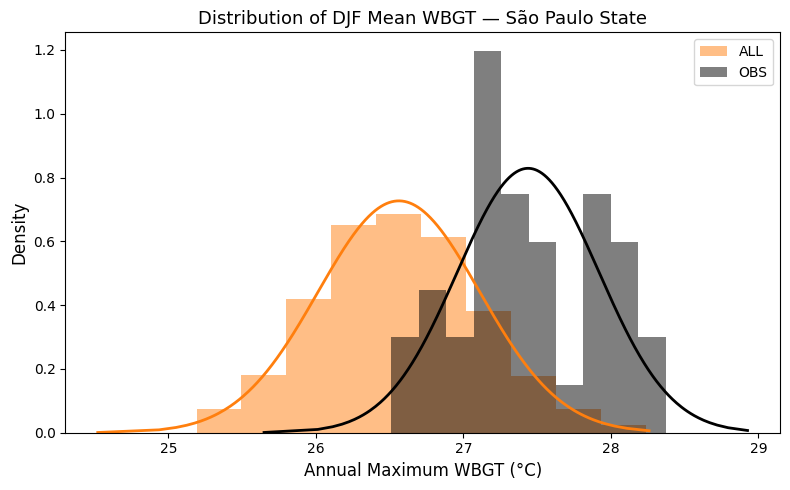

In [53]:
# ── Validation: Histogram plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

eea.validation.histogram_plot(
    ax,
    obs=obs_djf_val,
    all=hist_djf_val,
    fit_function=fit_function
)

ax.set_xlabel('Annual Maximum WBGT (°C)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Distribution of {SEASON_LABEL} {TEMPORAL_AGG.capitalize()} {VAR_LABEL} — {REGION_NAME}', fontsize=13)
plt.tight_layout()
plt.show()

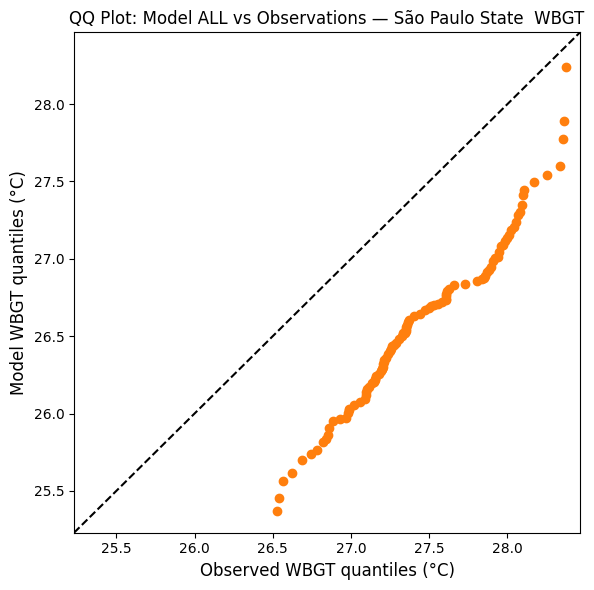

In [54]:
# ── Validation: QQ plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

eea.validation.qq_plot(
    ax,
    obs=obs_djf_val,
    all=hist_djf_val
)

ax.set_xlabel('Observed WBGT quantiles (°C)', fontsize=12)
ax.set_ylabel('Model WBGT quantiles (°C)', fontsize=12)
ax.set_title(f'QQ Plot: Model ALL vs Observations — {REGION_NAME}  {VAR_LABEL}', fontsize=12)
plt.tight_layout()
plt.show()

### Interpreting Validation Plots

Look at the two plots above and think about these questions:

1. Is the model mean higher or lower than observations?
2. Does the model capture the spread (variance) of observations?
3. In the QQ plot, does the model overestimate or underestimate extreme values?
4. Do you need any type of bias correction? Why or why not?

In [55]:
# ── Bias correction ────────────────────────────────────────────────────────
# Controlled by BIAS_CORRECTION_METHOD in the config cell.
# Set to None to skip (recommended for SPEI and other normalised indices).

if BIAS_CORRECTION_METHOD is not None:
    # Scale hist and obs against their own reference period climatology
    hist_djf_bc = eea.correction.scaling(hist_djf, hist_djf, CLIM_PERIOD[0], CLIM_PERIOD[1], method=BIAS_CORRECTION_METHOD)
    obs_djf_bc  = eea.correction.scaling(obs_djf,  obs_djf,  CLIM_PERIOD[0], CLIM_PERIOD[1], method=BIAS_CORRECTION_METHOD)

    obs_djf_bc_val  = obs_djf_bc.sel(time=common_years)
    hist_djf_bc_val = hist_djf_bc.sel(time=common_years)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    eea.validation.histogram_plot(ax1, obs_djf_bc_val, hist_djf_bc_val, fit_function)
    eea.validation.qq_plot(ax2, obs_djf_bc_val, hist_djf_bc_val)

    ax1.set_xlabel(f'{SEASON_LABEL} {TEMPORAL_AGG.capitalize()} {VAR_LABEL}')
    ax1.set_ylabel('PDF')
    ax2.set_xlabel('OBS')
    ax2.set_ylabel('HIST')
    fig.suptitle(f'Validation after {BIAS_CORRECTION_METHOD!r} bias correction', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Apply the same correction to ALL and NAT
    all_djf_bc = eea.correction.scaling(all_djf, hist_djf, CLIM_PERIOD[0], CLIM_PERIOD[1], method=BIAS_CORRECTION_METHOD)
    nat_djf_bc = eea.correction.scaling(nat_djf, hist_djf, CLIM_PERIOD[0], CLIM_PERIOD[1], method=BIAS_CORRECTION_METHOD)

    # Update working variables and recompute event threshold in corrected space
    obs_djf    = obs_djf_bc
    all_djf    = all_djf_bc
    nat_djf    = nat_djf_bc
    event_2024 = float(obs_djf.sel(time=EVENT_YEAR))
    threshold  = event_2024

    print(f"✅ {BIAS_CORRECTION_METHOD!r} bias correction applied to obs, ALL, and NAT")
    print(f"   Event ({SEASON_LABEL} {EVENT_YEAR}) in corrected space: {event_2024:.2f}")
else:
    print(f"⏭️  Bias correction skipped (BIAS_CORRECTION_METHOD = None)")
    print(f"   Event ({SEASON_LABEL} {EVENT_YEAR}) threshold: {threshold:.2f}")

⏭️  Bias correction skipped (BIAS_CORRECTION_METHOD = None)
   Event (DJF 2024) threshold: 28.41


---
## Section 5 — Fitting a Statistical Distribution

Attribution analysis requires fitting a probability distribution to the data so we can estimate probabilities for any threshold — not just values observed in the finite sample.

### Distribution choice for DJF means

Because we are working with **seasonal means** (rather than block maxima), the **Normal distribution** is the natural first choice — seasonal averages tend toward normality by the central limit theorem. A **Gamma** distribution can be used as a sensitivity check for right-skewed data.
A **GEV** would be a good option for block maxima, such as the maximum daily precipitation or temperature.

In [56]:
# ── Fit distributions to ALL and NAT ensembles ───────────────────────────────────
params_all = fit_function.fit(all_djf.values)
params_nat = fit_function.fit(nat_djf.values)

# loc and scale are always the last two parameters in scipy distributions;
# shape parameters (if any, e.g. GEV) come first.
loc_all, scale_all = params_all[-2], params_all[-1]
loc_nat, scale_nat = params_nat[-2], params_nat[-1]

print(f"{fit_function.name} fit — ALL forcing:")
print(f"  location = {loc_all:.2f}  |  scale = {scale_all:.2f}")
print()
print(f"{fit_function.name} fit — NAT forcing:")
print(f"  location = {loc_nat:.2f}  |  scale = {scale_nat:.2f}")
print()
print(f"Shift in location parameter (ALL - NAT): {loc_all - loc_nat:.2f}")
print("→ This is the anthropogenic shift in the typical seasonal value")

norm fit — ALL forcing:
  location = 27.30  |  scale = 0.49

norm fit — NAT forcing:
  location = 25.95  |  scale = 0.51

Shift in location parameter (ALL - NAT): 1.36
→ This is the anthropogenic shift in the typical seasonal value


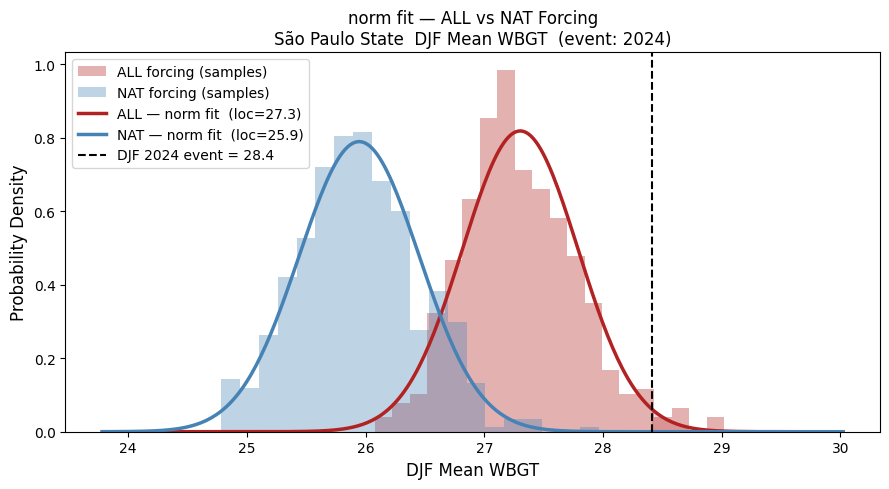

In [57]:
# ── Visualise fitted distributions ───────────────────────────────────────────────
x = np.linspace(
    min(all_djf.values.min(), nat_djf.values.min()) - 1,
    max(all_djf.values.max(), nat_djf.values.max()) + 1,
    300
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(all_djf.values, bins=20, alpha=0.35, color='firebrick',
        density=True, label='ALL forcing (samples)')
ax.hist(nat_djf.values, bins=20, alpha=0.35, color='steelblue',
        density=True, label='NAT forcing (samples)')

ax.plot(x, fit_function.pdf(x, *params_all), color='firebrick', lw=2.5,
        label=f'ALL — {fit_function.name} fit  (loc={loc_all:.1f})')
ax.plot(x, fit_function.pdf(x, *params_nat), color='steelblue', lw=2.5,
        label=f'NAT — {fit_function.name} fit  (loc={loc_nat:.1f})')

ax.axvline(threshold, color='black', linestyle='--', lw=1.5,
           label=f'{SEASON_LABEL} {EVENT_YEAR} event = {threshold:.1f}')

x_exc = x[x <= threshold] if DIRECTION == 'ascending' else x[x >= threshold]
ax.fill_between(x_exc, fit_function.pdf(x_exc, *params_all), alpha=0.2, color='firebrick')
ax.fill_between(x_exc, fit_function.pdf(x_exc, *params_nat), alpha=0.2, color='steelblue')

ax.set_xlabel(f'{SEASON_LABEL} {TEMPORAL_AGG.capitalize()} {VAR_LABEL}', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(
    f'{fit_function.name} fit — ALL vs NAT Forcing\n'
    f'{REGION_NAME}  {SEASON_LABEL} {TEMPORAL_AGG.capitalize()} {VAR_LABEL}  (event: {EVENT_YEAR})',
    fontsize=12
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Reading the Distribution Plot

1. The shaded areas represent the probability of exceeding the threshold. Which world (ALL or NAT) has higher exceedance probability?
2. Estimate visually: how much warmer is the ALL-forcing distribution compared to NAT-forcing?
3. Why do we use a threshold from *observations* rather than from the model itself?


---
## Section 6 — Attribution Metrics

We now compute the core attribution metrics using `climattr.attribution.attribution_metrics`.

The function computes PR and FAR with **bootstrap confidence intervals** to account for sampling uncertainty in the finite ensemble.

### Interpreting PR and FAR

| PR | Interpretation |
|----|----------------|
| PR = 0.5 | Event is 50% less likely due to climate change |
| PR = 1   | No change in likelihood — climate change had no effect |
| PR = 2   | Event is twice as likely due to climate change |
| PR = 5   | Event is 5× more likely |
| PR → ∞   | Event was essentially impossible without climate change |

| FAR | Interpretation |
|-----|----------------|
| FAR = 0 | None of the risk is attributable to climate change |
| FAR = 0.5 | Half the probability is attributable to climate change |
| FAR = 1 | All of the probability is attributable to climate change |

---

### Limitations of FAR for impact attribution

FAR is a widely reported metric, but it has important limitations when used to attribute **impacts** (rather than the meteorological event itself). Perkins-Kirkpatrick et al. (2022) argue that FAR is often misapplied in impact attribution contexts for the following reasons:

**1. FAR characterises a class of events, not a specific impact.**
FAR measures the change in the *frequency* of events at least as extreme as the chosen threshold — it does not measure the change in the *magnitude* of any particular event. When impacts depend on how extreme an event was (e.g., heat-related deaths increase sharply above a physiological threshold), using FAR from the meteorological event can misrepresent the attributable fraction of the impact.

**2. FAR does not cleanly transfer from hazard to impact.**
The authors conclude that *"the anthropogenic signal from the extreme event does not seamlessly transfer to impacts"*, meaning a FAR of 0.8 on the meteorological variable does not imply that 80% of the observed impact is attributable to climate change.

> **Reference:** Perkins-Kirkpatrick, S. E., Stone, D. A., Mitchell, D. M., Rosier, S., King, A. D., Lo, Y. T. E., Pastor-Paz, J., Frame, D., & Wehner, M. (2022). On the attribution of the impacts of extreme weather events to anthropogenic climate change. *Environmental Research Letters*, 17(2). https://doi.org/10.1088/1748-9326/ac44c8

In [58]:
# ── Compute attribution metrics ────────────────────────────────────────────
print(f"Computing attribution for threshold = {threshold:.2f}...")

metrics = eea.attribution.attribution_metrics(
    all=all_djf,
    nat=nat_djf,
    fit_function=fit_function,
    thresh=threshold,
    direction=DIRECTION,
)

print()
print("═" * 50)
print(f"  ATTRIBUTION RESULTS — {REGION_NAME}  {SEASON_LABEL} {VAR_LABEL}")
print("═" * 50)
print(metrics)
print("═" * 50)

Computing attribution for threshold = 28.41...

══════════════════════════════════════════════════
  ATTRIBUTION RESULTS — São Paulo State  DJF WBGT
══════════════════════════════════════════════════
                   PR       FAR      RP_ALL        RP_NAT
value    25570.368190  0.999961   88.346281  1.923112e+06
ci_inf    4679.839100  0.999786   55.261885  3.958990e+05
ci_sup  155884.260671  0.999994  146.778765  1.199517e+07
══════════════════════════════════════════════════


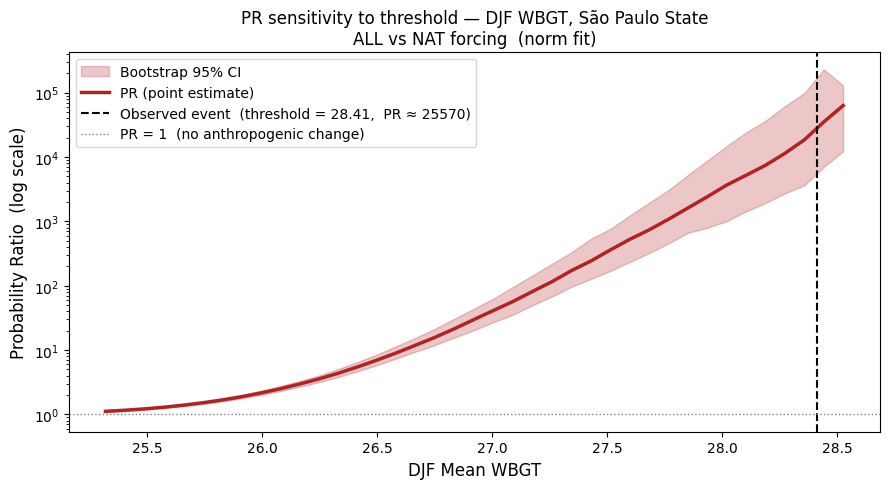

In [59]:
# ── PR sensitivity to threshold ─────────────────────────────────────────────
# Compute attribution metrics (with bootstrap CI) across a range of threshold
# values. Increase n_thresh for a smoother curve at the cost of compute time.
# The range is capped at the 5th–99th percentile of the combined ensemble to
# avoid extreme tails where P_NAT ≈ 0 and the bootstrap produces only NaNs.

n_thresh = 40

combined     = np.concatenate([all_djf.values.ravel(), nat_djf.values.ravel()])
thresh_lo    = np.percentile(combined, 5)
thresh_hi    = max(np.percentile(combined, 99), threshold + 0.2)
thresh_range = np.linspace(thresh_lo, thresh_hi, n_thresh)

pr_values  = []
pr_ci_inf  = []
pr_ci_sup  = []
thresh_used = []

for t in thresh_range:
    try:
        m = eea.attribution.attribution_metrics(
            all=all_djf,
            nat=nat_djf,
            fit_function=fit_function,
            thresh=float(t),
            direction=DIRECTION,
        )
        pr_values.append(float(m.loc['value', 'PR']))
        pr_ci_inf.append(float(m.loc['ci_inf', 'PR']))
        pr_ci_sup.append(float(m.loc['ci_sup', 'PR']))
        thresh_used.append(float(t))
    except (IndexError, ValueError, KeyError):
        pass   # skip thresholds where the bootstrap has no valid samples

thresh_used = np.array(thresh_used)
pr_values   = np.array(pr_values)
pr_ci_inf   = np.array(pr_ci_inf)
pr_ci_sup   = np.array(pr_ci_sup)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(thresh_used, pr_ci_inf, pr_ci_sup,
                color='firebrick', alpha=0.25, label='Bootstrap 95% CI')
ax.plot(thresh_used, pr_values, color='firebrick', lw=2.5, label='PR (point estimate)')
ax.axvline(
    threshold, color='black', linestyle='--', lw=1.5,
    label=f'Observed event  (threshold = {threshold:.2f},  PR ≈ {float(metrics.loc["value", "PR"]):.0f})'
)
ax.axhline(1, color='gray', linestyle=':', lw=1, label='PR = 1  (no anthropogenic change)')

ax.set_yscale('log')
ax.set_xlabel(f'{SEASON_LABEL} {TEMPORAL_AGG.capitalize()} {VAR_LABEL}', fontsize=12)
ax.set_ylabel('Probability Ratio  (log scale)', fontsize=12)
ax.set_title(
    f'PR sensitivity to threshold — {SEASON_LABEL} {VAR_LABEL}, {REGION_NAME}\n'
    f'ALL vs NAT forcing  ({fit_function.name} fit)',
    fontsize=12
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

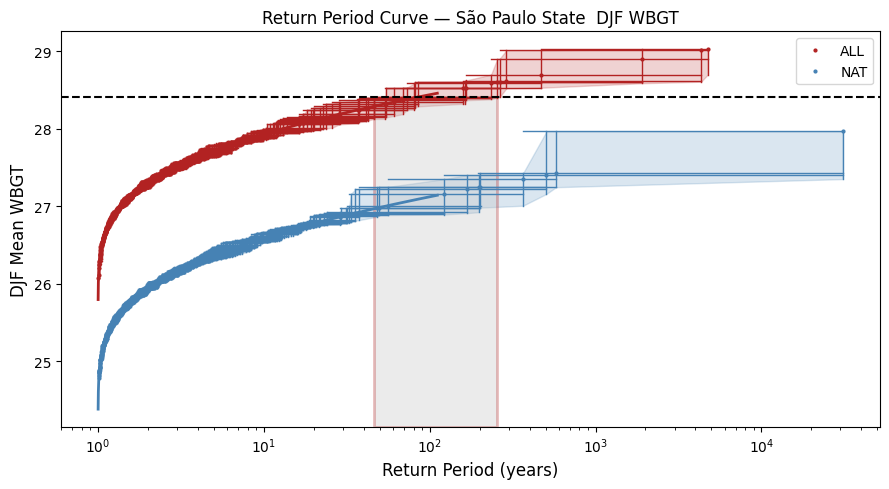

In [60]:
# ── Return Period plot ─────────────────────────────────────────────────────
# The return period plot shows how often events of different magnitudes occur
# in each world. A lower return period = more frequent event.

fig, ax = plt.subplots(figsize=(9, 5))

eea.attribution.rp_plot(
    ax,
    all=all_djf,
    nat=nat_djf,
    fit_function=fit_function,
    thresh=threshold,
    direction=DIRECTION,
    all_color='firebrick',
    nat_color='steelblue'
)

ax.set_xlabel('Return Period (years)', fontsize=12)
ax.set_ylabel(f'{SEASON_LABEL} {TEMPORAL_AGG.capitalize()} {VAR_LABEL}', fontsize=12)
ax.set_title(f'Return Period Curve — {REGION_NAME}  {SEASON_LABEL} {VAR_LABEL}', fontsize=12)
plt.tight_layout()
plt.show()

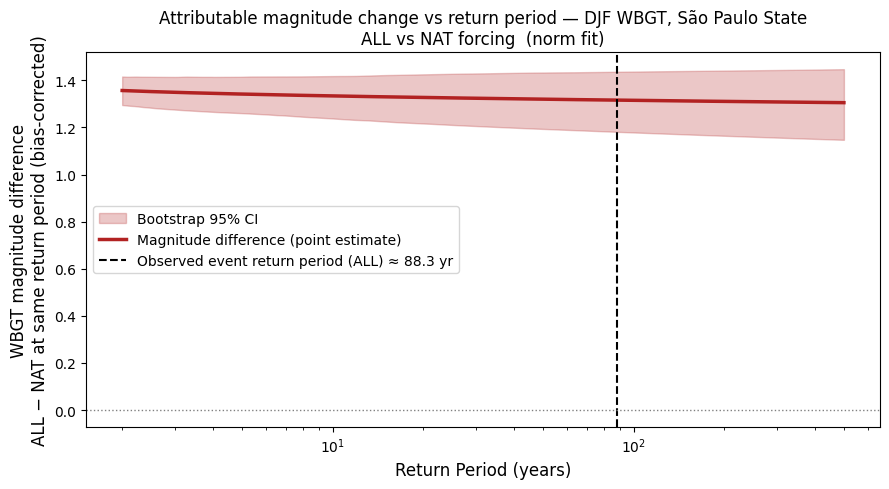

In [61]:
# ── Attributable magnitude change vs return period (with bootstrap CI) ──────
# For each return period T, the magnitude difference ALL − NAT answers:
# "By how much more intense is a 1-in-T event due to anthropogenic forcing?"
# Uncertainty is estimated by resampling ALL and NAT independently, refitting
# the distribution, and recomputing the difference (n_boot iterations).

n_boot   = 500                                             # increase for tighter CI at cost of time
rp_range = np.logspace(np.log10(2), np.log10(500), 300)
p_exc    = 1.0 / rp_range

# ── Point estimate ────────────────────────────────────────────────────────
mag_all  = fit_function.ppf(1 - p_exc, *params_all)
mag_nat  = fit_function.ppf(1 - p_exc, *params_nat)
mag_diff = mag_all - mag_nat

# ── Bootstrap CI ─────────────────────────────────────────────────────────
rng         = np.random.default_rng(42)
boot_diffs  = np.empty((n_boot, len(rp_range)))

for i in range(n_boot):
    p_all_b = fit_function.fit(
        rng.choice(all_djf.values, size=len(all_djf.values), replace=True)
    )
    p_nat_b = fit_function.fit(
        rng.choice(nat_djf.values, size=len(nat_djf.values), replace=True)
    )
    boot_diffs[i] = (fit_function.ppf(1 - p_exc, *p_all_b)
                     - fit_function.ppf(1 - p_exc, *p_nat_b))

ci_inf = np.percentile(boot_diffs, 2.5,  axis=0)
ci_sup = np.percentile(boot_diffs, 97.5, axis=0)

rp_event = float(metrics.loc['value', 'RP_ALL'])

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(rp_range, ci_inf, ci_sup,
                color='firebrick', alpha=0.25, label='Bootstrap 95% CI')
ax.plot(rp_range, mag_diff, color='firebrick', lw=2.5, label='Magnitude difference (point estimate)')
ax.axvline(
    rp_event, color='black', linestyle='--', lw=1.5,
    label=f'Observed event return period (ALL) ≈ {rp_event:.1f} yr'
)
ax.axhline(0, color='gray', linestyle=':', lw=1)

ax.set_xscale('log')
ax.set_xlabel('Return Period (years)', fontsize=12)
ax.set_ylabel(
    f'{VAR_LABEL} magnitude difference\nALL − NAT at same return period (bias-corrected)',
    fontsize=12
)
ax.set_title(
    f'Attributable magnitude change vs return period — {SEASON_LABEL} {VAR_LABEL}, {REGION_NAME}\n'
    f'ALL vs NAT forcing  ({fit_function.name} fit)',
    fontsize=12
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 7 — Interpretation & Discussion

### Communicating attribution results

Attribution results must be communicated carefully. Key points:

- **PR and FAR are ensemble estimates** — they represent the behaviour of many model simulations, not a single event
- **Confidence intervals matter** — a PR of 2 with wide intervals (0.8–10) is very different from PR = 2 (1.5–3.0)
- **The threshold choice affects the result** — higher thresholds (rarer events) often show larger PRs
- **Model uncertainty is not fully captured** — results from a single model family (HadGEM3-A) may differ from a multi-model assessment

### Discussion questions

Based on your results, consider the following:

1. **What does your PR tell you?** Translate it into plain language: how many times more (or less) likely was DJF 2024 in a world with human influence compared to a world without?
2. **Is your confidence interval narrow or wide?** What does that imply about the robustness of the attribution signal?
3. **How would the result change if you used a higher or lower threshold?** Try shifting the threshold by ±0.5°C and re-running Section 6.
4. **How would you communicate this result to a policymaker?** Try writing one sentence suitable for a press release.